In [1]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

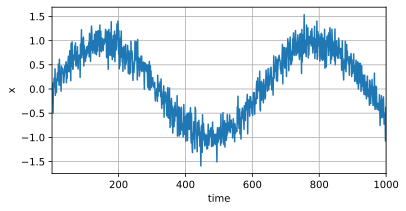

In [2]:
class Data(d2l.DataModule):
    def __init__(self, batch_size=16, T=1000, num_train=600, tau=4):
        self.save_hyperparameters()
        self.time = torch.arange(1, T + 1, dtype=torch.float32)
        self.x = torch.sin(0.01 * self.time) + torch.randn(T) * 0.2

data = Data()
d2l.plot(data.time, data.x, 'time', 'x', xlim=[1, 1000], figsize=(6, 3))

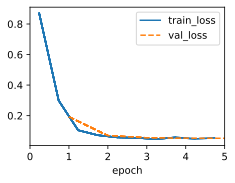

In [3]:
@d2l.add_to_class(Data)
def get_dataloader(self, train):
    features = [self.x[i : self.T-self.tau+i] for i in range(self.tau)]
    self.features = torch.stack(features, 1)
    self.labels = self.x[self.tau:].reshape((-1, 1))
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader([self.features, self.labels], train, i)

model = d2l.LinearRegression(lr=0.01)
trainer = d2l.Trainer(max_epochs=5)
trainer.fit(model, data)

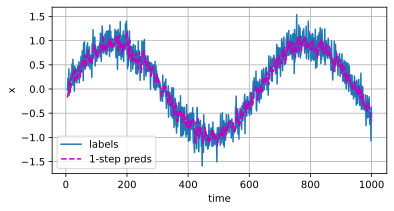

In [4]:
onestep_preds = model(data.features).detach().numpy()
d2l.plot(data.time[data.tau:], [data.labels, onestep_preds], 'time', 'x',
         legend=['labels', '1-step preds'], figsize=(6, 3))

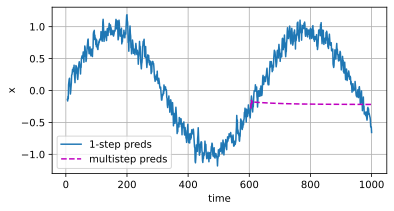

In [8]:
multistep_preds = torch.zeros(data.T)
multistep_preds[:] = data.x

for i in range(data.num_train + data.tau, data.T):
    multistep_preds[i] = model(
        multistep_preds[i - data.tau:i].reshape((1, -1)))
    
multistep_preds = multistep_preds.detach().numpy()

d2l.plot([data.time[data.tau:], data.time[data.num_train+data.tau:]],
         [onestep_preds, multistep_preds[data.num_train+data.tau:]], 'time',
         'x', legend=['1-step preds', 'multistep preds'], figsize=(6, 3))

In [ ]:
def k_step_pred(k):
    features = []
    for i in range(data.tau):
        features.append(data.x[i : i+data.T-data.tau-k+1])
    # The (i+tau)-th element stores the (i+1)-step-ahead predictions
    for i in range(k):
        preds = model(torch.stack(features[i : i+data.tau], 1))
        features.append(preds.reshape(-1))
    return features[data.tau:]

steps = (1, 4, 16, 64)
preds = k_step_pred(steps[-1])
d2l.plot(data.time[data.tau+steps[-1]-1:],
         [preds[k - 1].detach().numpy() for k in steps], 'time', 'x',
         legend=[f'{k}-step preds' for k in steps], figsize=(6, 3))

In [14]:
preds[3]


tensor([-0.2667, -0.1094, -0.0724,  0.0513,  0.1482,  0.1002,  0.2553,  0.0447,
         0.0391,  0.0054, -0.0571,  0.0721,  0.1091,  0.2137,  0.2572,  0.2095,
         0.3525,  0.3262,  0.2116,  0.4079,  0.3508,  0.3485,  0.2219,  0.2396,
         0.0751,  0.2609,  0.3076,  0.3067,  0.3778,  0.3749,  0.3440,  0.2441,
         0.1793,  0.1847,  0.2113,  0.3261,  0.3891,  0.3669,  0.4360,  0.4691,
         0.2923,  0.3631,  0.2575,  0.3601,  0.3422,  0.4571,  0.5442,  0.5060,
         0.4386,  0.5045,  0.5989,  0.5536,  0.5451,  0.3517,  0.6108,  0.5758,
         0.5299,  0.7524,  0.5940,  0.5115,  0.4589,  0.4807,  0.5540,  0.5598,
         0.6660,  0.7436,  0.7261,  0.8264,  0.6453,  0.5579,  0.6158,  0.6374,
         0.5627,  0.7108,  0.5775,  0.4940,  0.5764,  0.5780,  0.6045,  0.6037,
         0.6334,  0.4231,  0.6599,  0.7100,  0.7472,  0.9810,  0.7769,  0.9063,
         0.8274,  0.8178,  0.7491,  0.8730,  0.6445,  0.7677,  0.7233,  0.7353,
         0.7179,  0.6247,  0.6496,  0.61